In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py
import numpy as np
import json
from datetime import datetime

In [2]:

def projectDistZ(x1,x2,y1,y2,d12,z):
    mx = (x2-x1)/d12
    xProj = x1 + mx * z
    
    my = (y2-y1)/d12
    yProj = y1 + my * z
    
    return (xProj, yProj)

def get_theta_angles(x1, y1, x2, y2, d):
    import numpy as np
    thetaX = np.arctan((x2-x1)/d) #rad
    thetaY = np.arctan((y2-y1)/d) #rad
    return (thetaX, thetaY)

    
def file_loader(runs):
    from collections.abc import Iterable

    if not isinstance(runs, Iterable):
        runs = [runs]

    pos = []
    phs = []
    tmis = []
    qtots = []
    nclus = []
    info_pluss = []
    xinfos = []
    n_spill_list = []

    for run_number in runs:
        data_path = f'/eos/project/i/insulab-como/testBeam/TB_2025_06_T9_epBOOST/HDF5/run{run_number}.h5'
        # data_path = f'../data/run{run_number}.h5'
        with h5py.File(data_path, 'r', libver='latest', swmr=True) as hf:
            pos.append(np.array(hf['xpos']))
            phs.append(np.array(hf['digiPH']))
            tmis.append(np.array(hf['digiTime']))
            qtots.append(np.array(hf['qtot']))
            nclus.append(np.array(hf['nclu']))
            info_plus = np.array(hf['info_plus'])
            xinfo = np.array(hf['xinfo'])
            info_pluss.append(info_plus)
            xinfos.append(xinfo)

            n_spill = int(np.max(info_plus[:, 0]))
            n_spill_list.append(n_spill)
            print(f'Run {run_number} — N spill: {n_spill} — events: {len(hf["xpos"])} — evs/spill: {len(hf["xpos"]) / n_spill:.0f}')

    xpos = np.concatenate(pos, axis=0)
    ph = np.concatenate(phs, axis=0)
    tm = np.concatenate(tmis, axis=0)
    qtot = np.concatenate(qtots, axis=0)
    nclu = np.concatenate(nclus, axis=0)
    info_plus = np.concatenate(info_pluss, axis=0)
    xinfo = np.concatenate(xinfos, axis=0)

    logic_pos = (xpos[:, :6] > -1) & (xpos[:, :6] < 15)
    
    logic = logic_pos.all(axis = 1)
    xpos= xpos[logic]
    ph= ph[logic]
    tm= tm[logic]
    qtot= qtot[logic]
    nclu= nclu[logic]
    info_plus= info_plus[logic]
    xinfo= xinfo[logic]
    # Apply offsets
    xpos[:, 0] -= offset_x1
    xpos[:, 1] -= offset_y1
    xpos[:, 4] -= offset_x3
    xpos[:, 5] -= offset_y3

    x1 = xpos[:, 0]
    y1 = xpos[:, 1]
    x2 = xpos[:, 2]
    y2 = xpos[:, 3]
    x3 = xpos[:, 4]
    y3 = xpos[:, 5]

    Calibration = False
    if Calibration:
        q = -25.84
        m = 323.4
        ph[:, 2] = (ph[:, 2] - q) / m

    xcry, ycry = projectDistZ(x1, x2, y1, y2, d12, d1c)
    theta_x_in, theta_y_in = get_theta_angles(x1, y1, x2, y2, d12)
    theta_x_out, theta_y_out = get_theta_angles(xcry, ycry, x3, y3, dc3)

    ph_calo_photon = ph[:, 2]
    ph_cherry1 = ph[:, 0]

    total_spills = sum(n_spill_list)
    print(f"{runs} — TOTAL SPILLS: {total_spills} — TOTAL EVENTS: {len(x1)}")

    return xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
           theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo


In [3]:
# scan_number = [730301] #, 730315] ## if amorphous put it first
# scan_number = [730256,730286,730289,730290,730292,730293,730294,730295,730296,\
               # 730297,730298,730299,730301,730264,730265,730266,730267,730278,\
               # 730311,730312,730314, 730315,730316,730317]
# scan_number = [730289,730301,730314,730315]
scan_number = [730160,730161,730162,730163,730164,730165,730166,\
               730178,730179,730180,730181,730218,730219,730220,730221,730226,730325,730326] #730222,[730172,730173,730174,730175,730176]
x_cry_cut = [4.45, 4.9]
y_cry_cut = [7, 7.5]

# theta_cut = 543.7
theta_cut = 100000000000000000



d12 = 330 ## cm
d23 = 66.8
d1c = 330 + 53.2 #cm
dc3 = 10.7 
d1calo = d1c + 779.2 


offset_x1 =   0.107 #0.166
offset_y1 =   -2.21 #-2.336
offset_x3 =   0.484 #0.459
offset_y3 =   -2.053 #-2.031 


range_chamber = ((0,10),(0,10))
bins2d = (100,100)
mycmap = 'jet'

opt_hist = {'histtype': 'step', 'lw': 1.5, 'alpha': 0.8}
opts_2d = { "cmap" : mycmap, "bins" : bins2d} # "norm" : mpl.colors.LogNorm()}

th_cherry1 = 20
th_cherry2 = 20
th_calo = 0

Run 730160 — N spill: 81 — events: 29951 — evs/spill: 370
[730160] — TOTAL SPILLS: 81 — TOTAL EVENTS: 29557
events in base mask: 734
Run 730161 — N spill: 52 — events: 20134 — evs/spill: 387
[730161] — TOTAL SPILLS: 52 — TOTAL EVENTS: 19867
events in base mask: 522
Run 730162 — N spill: 45 — events: 17541 — evs/spill: 390
[730162] — TOTAL SPILLS: 45 — TOTAL EVENTS: 17303
events in base mask: 410
Run 730163 — N spill: 67 — events: 26113 — evs/spill: 390
[730163] — TOTAL SPILLS: 67 — TOTAL EVENTS: 25756
events in base mask: 684
Run 730164 — N spill: 44 — events: 16531 — evs/spill: 376
[730164] — TOTAL SPILLS: 44 — TOTAL EVENTS: 16305
events in base mask: 395
Run 730165 — N spill: 71 — events: 27178 — evs/spill: 383
[730165] — TOTAL SPILLS: 71 — TOTAL EVENTS: 26790
events in base mask: 663
Run 730166 — N spill: 33 — events: 12887 — evs/spill: 391
[730166] — TOTAL SPILLS: 33 — TOTAL EVENTS: 12724
events in base mask: 308
Run 730178 — N spill: 68 — events: 13374 — evs/spill: 197
[730178] — 

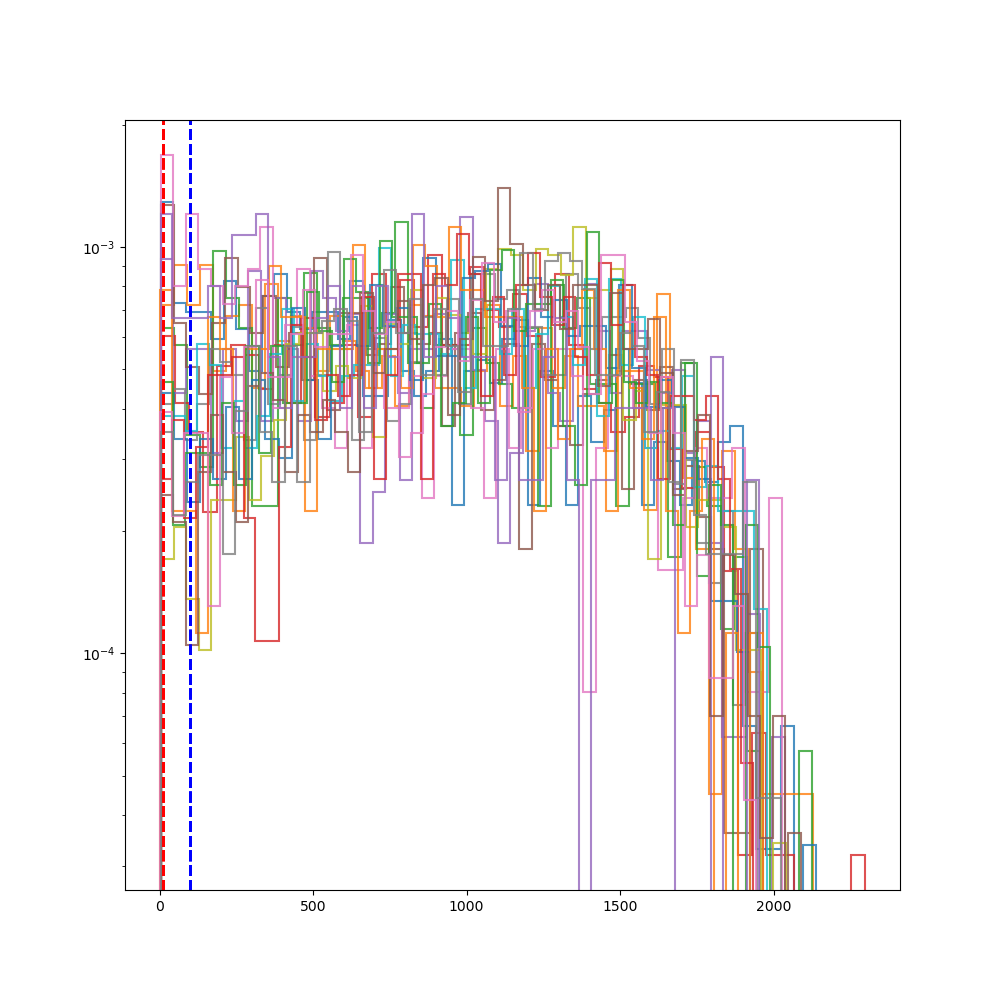

In [6]:
# Define what to compute
observables = ['ph', 'qtot', 'nclu', 'si', 'x3', 'y3', 'std_x3', 'std_y3']

Force_min_max = 'min' # 'min max 
photon_min = 100
photon_max = 10

show_plots = True


# Define conditional logic per observable
mask_modifiers = {
    'x3': lambda: (x3 > 3) & (x3 < 6) & (nclu[:, 0] == 1),
    'std_x3': lambda: (x3 > 3) & (x3 < 6) & (nclu[:, 0] == 1),
    'y3': lambda: (x3 > 3) & (x3 < 6) & (nclu[:, 0] == 1),  # optional
    'std_y3': lambda: (x3 > 3) & (x3 < 6) & (nclu[:, 0] == 1),
    'qtot': lambda: (nclu[:, 0] > 1),
    'si': lambda: (nclu[:, 0] > 1),
    'nclu': lambda: (nclu[:, 0] > 1),
    'ph': (
        lambda: ((nclu[:, 0] == 1) &
                 ((ph_calo_photon < photon_min) if Force_min_max == 'min'
                  else (ph_calo_photon > photon_max)))
    )
}

if show_plots:
    fig, ax = plt.subplots(1, figsize = (10,10))    
# Output dictionary: keyed by (rot, crad)
data_joint = {}

for run in scan_number:
    # Load data
    if np.any(run) > 730198:
        xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
        theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo = file_loader(run)
    else:
        _, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
        theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo = file_loader(run)

    # Base mask
    base_mask = (ph_cherry1 > th_cherry1) & \
                (xcry > x_cry_cut[0]) & (xcry < x_cry_cut[1]) & \
                (ycry > y_cry_cut[0]) & (ycry < y_cry_cut[1]) & \
                (ph_calo_photon > th_calo) & \
                (((theta_x_in)**2 + (theta_y_in)**2) < (theta_cut**2))

    print(f'events in base mask: {np.sum(base_mask)}')
    if show_plots:
        ax.hist(ph_calo_photon[base_mask],bins = 50, density = True, label = f'{run}', **opt_hist )
        ax.axvline(x = photon_min, c = 'b', ls = '--', lw = 2 ) 
        ax.axvline(x = photon_max, c = 'r', ls = '--', lw = 2 ) 
        ax.set_yscale('log')
    for obs in observables:
        # Combine base + modifier mask
        full_mask = base_mask & mask_modifiers[obs]()
        for i in np.where(full_mask)[0]:
            r = round(xinfo[i, 0], 6)
            c = round(xinfo[i, 1], 6)
            key = (r, c)
            if key not in data_joint:
                data_joint[key] = {
                    'ph': [], 'qtot': [], 'nclu': [], 'si': [],
                    'x3': [], 'y3': [], 'rot': r, 'crad': c
                }

            if obs == 'ph':
                data_joint[key]['ph'].append(ph_calo_photon[i])
            elif obs == 'qtot':
                data_joint[key]['qtot'].append(qtot[i, 0])
            elif obs == 'nclu':
                data_joint[key]['nclu'].append(nclu[i, 0])
            elif obs == 'si':
                # Compute single-event spectral intensity (approx.)
                data_joint[key]['si'].append(ph_calo_photon[i])  # can be refined
            elif obs == 'x3':
                data_joint[key]['x3'].append(x3[i])
            elif obs == 'y3':
                data_joint[key]['y3'].append(y3[i])


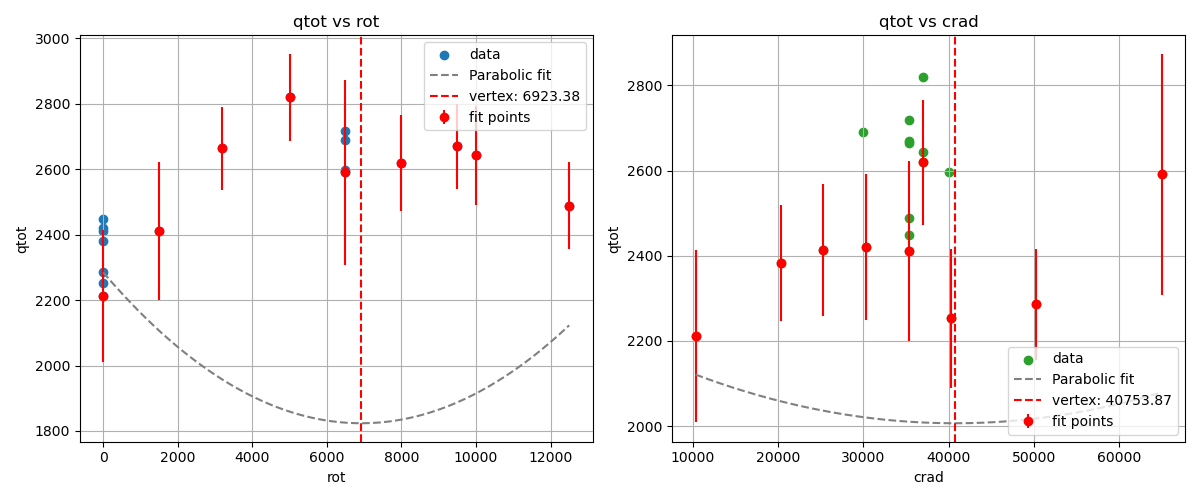

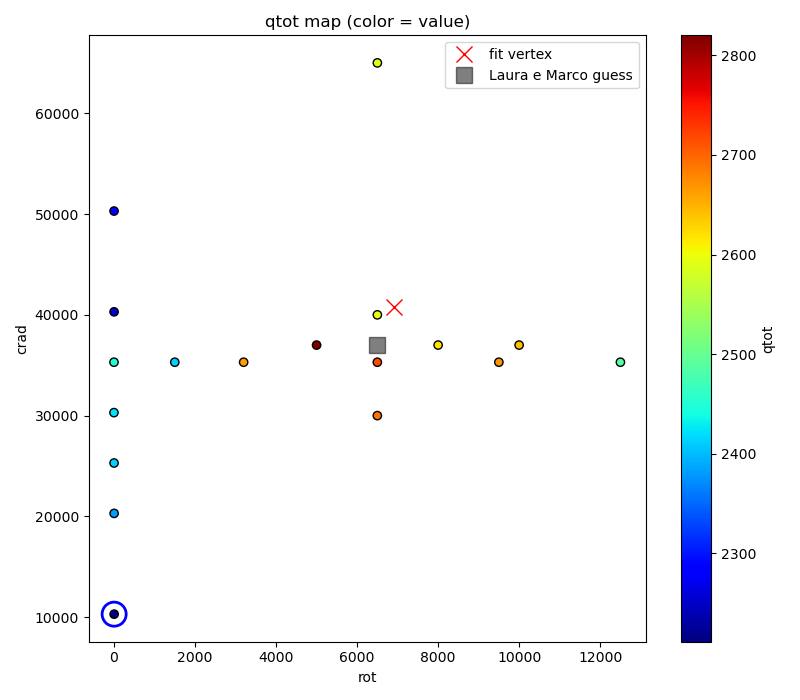

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from matplotlib.patches import Circle

# === PARAMETRI CONFIGURABILI ===
key_name = 'qtot'         # 'ph', 'qtot', 'nclu', 'si', 'x3', 'y3', 'std_x3', 'std_y3'
skip_first = False           # Salta il primo punto nel fit
show_first = True          # Mostra il primo punto nei plot

# === FUNZIONE PARABOLA PER IL FIT ===
def parabola(x, a, b, c):
    return a * x**2 + b * x + c

def safe_fit(x, y, yerr, force='max'):  # force: 'max', 'min', or None
    try:
        popt, pcov = curve_fit(parabola, x, y, sigma=yerr, absolute_sigma=True)
        
        if force == 'max' and popt[0] > 0:
            popt[0] *= -1
            popt[1] *= -1
        elif force == 'min' and popt[0] < 0:
            popt[0] *= -1
            popt[1] *= -1

        vertex = -popt[1] / (2 * popt[0])
        xfit = np.linspace(min(x), max(x), 300)
        yfit = parabola(xfit, *popt)
        return vertex, xfit, yfit, popt, pcov
    except Exception as e:
        print(f"[!] Fit failed: {e}")
        return np.nan, np.array([]), np.array([]), None, None



# === COSTRUISCI ARRAY DEI RISULTATI ===
results = []
for (r, c), values in data_joint.items():
    if key_name.startswith("std_"):
        arr = values[key_name[4:]]
        val = np.std(arr) if len(arr) > 0 else np.nan
    else:
        arr = values[key_name]
        val = np.mean(arr) if len(arr) > 0 else np.nan
    results.append((r, c, val))

results = np.array(results)
r_vals = results[:, 0]
c_vals = results[:, 1]
z_vals = results[:, 2]

# === ROUND A ROT E CRAD ALLA DECINA (-1) o al CENTINAIO (-2) ===
r_rounded = np.round(r_vals, -2)
c_rounded = np.round(c_vals, -3)

# === TROVA VALORI MASSIMI DI Z PER OGNI ROT TONDA E CRAD TONDA ===
unique_r = np.unique(r_rounded)
unique_c = np.unique(c_rounded)

r_best = []
z_r_best = []
n_r_best = []
for r in unique_r:
    mask = r_rounded == r
    if Force_min_max == 'max':
        idx = np.nanargmax(z_vals[mask])
    else:
        idx = np.nanargmin(z_vals[mask])
    r_best.append(r_vals[mask][idx])
    z_r_best.append(z_vals[mask][idx])
    n_r_best.append(len(data_joint[(r_vals[mask][idx], c_vals[mask][idx])][key_name if not key_name.startswith("std_") else key_name[4:]]))

c_best = []
z_c_best = []
n_c_best = []
for c in unique_c:
    mask = c_rounded == c
    if Force_min_max == 'max':
        idx = np.nanargmax(z_vals[mask])
    else:
        idx = np.nanargmin(z_vals[mask])
    c_best.append(c_vals[mask][idx])
    z_c_best.append(z_vals[mask][idx])
    n_c_best.append(len(data_joint[(r_vals[mask][idx], c_vals[mask][idx])][key_name if not key_name.startswith("std_") else key_name[4:]]))


# === RIMUOVI IL PRIMO PUNTO SE skip_first ===
r_best = np.array(r_best)
z_r_best = np.array(z_r_best)
n_r_best = np.array(n_r_best)

c_best = np.array(c_best)
z_c_best = np.array(z_c_best)
n_c_best = np.array(n_c_best)

if skip_first:
    r_best = r_best[1:]
    z_r_best = z_r_best[1:]
    n_r_best = n_r_best[1:]

    c_best = c_best[1:]
    z_c_best = z_c_best[1:]
    n_c_best = n_c_best[1:]


# === FIT ===
z_r_err = np.array(z_r_best) / np.sqrt(n_r_best)  # o altra formula più precisa
z_c_err = np.array(z_c_best) / np.sqrt(n_c_best)  # o altra formula più precisa

vertex_rot, xfit_rot, yfit_rot, _, _ = safe_fit(r_best, z_r_best, z_r_err,force=Force_min_max)
vertex_crad, xfit_crad, yfit_crad, _, _ = safe_fit(c_best, z_c_best, z_c_err,force=Force_min_max)

# === PLOT 1D ===
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- ROT ---
mask_plot = np.ones_like(r_vals, dtype=bool) if show_first else (r_vals != r_vals.min())
ax[0].scatter(r_vals[mask_plot], z_vals[mask_plot], c='tab:blue', label='data')
ax[0].errorbar(r_best, z_r_best, yerr=z_r_err, fmt='o', color='red', label='fit points')
# ax[0].scatter(r_best, z_r_best, facecolors='none', edgecolors='red', label='fit points')
if len(xfit_rot) > 0:
    ax[0].plot(xfit_rot, yfit_rot, '--', color='gray', label='Parabolic fit')
    ax[0].axvline(vertex_rot, color='red', linestyle='--', label=f'vertex: {vertex_rot:.2f}')
ax[0].set_xlabel('rot')
ax[0].set_ylabel(key_name)
ax[0].set_title(f'{key_name} vs rot')
ax[0].grid(True)
ax[0].legend()

# --- CRAD ---
mask_plot = np.ones_like(c_vals, dtype=bool) if show_first else (c_vals != c_vals.min())
ax[1].scatter(c_vals[mask_plot], z_vals[mask_plot], c='tab:green', label='data')
ax[1].errorbar(c_best, z_c_best, yerr=z_c_err, fmt='o', color='red', label='fit points')
# ax[1].scatter(c_best, z_c_best, facecolors='none', edgecolors='red', label='fit points')
if len(xfit_crad) > 0:
    ax[1].plot(xfit_crad, yfit_crad, '--', color='gray', label='Parabolic fit')
    ax[1].axvline(vertex_crad, color='red', linestyle='--', label=f'vertex: {vertex_crad:.2f}')
ax[1].set_xlabel('crad')
ax[1].set_ylabel(key_name)
ax[1].set_title(f'{key_name} vs crad')
ax[1].grid(True)
ax[1].legend(loc = 'lower right')

fig.tight_layout()
plt.show()

# === PLOT 2D MAP ===
fig2, ax2 = plt.subplots(figsize=(8, 7))
sc = ax2.scatter(r_vals, c_vals, c=z_vals, cmap='jet', edgecolors='k')
ax2.set_xlabel('rot')
ax2.set_ylabel('crad')
ax2.set_title(f'{key_name} map (color = value)')
plt.colorbar(sc, ax=ax2, label=key_name)


# Trova il punto con z massimo
idx_max = np.nanargmax(z_vals)
x_max = r_vals[idx_max]
y_max = c_vals[idx_max]
idx_min = np.nanargmin(z_vals)
x_min = r_vals[idx_min]
y_min = c_vals[idx_min]

# Crea un cerchio rosso trasparente
if Force_min_max == 'max':
    plt.scatter(x_max, y_max, s=300, facecolors='none', edgecolors='r', linewidths=2)
elif Force_min_max == 'min':
    plt.scatter(x_min, y_min, s=300, facecolors='none', edgecolors='b', linewidths=2)
    

# Aggiungi X rossa su (vertex_rot, vertex_crad)
# if not np.isnan(vertex_rot) and not np.isnan(vertex_crad):
ax2.plot(vertex_rot, vertex_crad, 'rx', markersize=12, label='fit vertex')
#     ax2.plot(3780, 35750, 'kx', markersize=12, label='Best guess')
#     ax2.plot(-3350, 31100, 'bx', markersize=12, label='Best guess + beam')
#     ax2.plot(215, 33425, 'gx', markersize=12, label='average')
    # ax2.legend()
ax2.plot(6500,37000,'ks', alpha = 0.5, markersize = 12, label= 'Laura e Marco guess')

# Aggiungi legenda se necessario
ax2.legend()
plt.tight_layout()
plt.show()